In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, Normalizer
from sklearn.pipeline import Pipeline

2024-03-28 21:12:42.577751: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-03-28 21:12:42.581282: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-03-28 21:12:42.607584: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-03-28 21:12:45.164357: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
tf.config.experimental.set_visible_devices([], 'GPU')

2024-03-28 21:14:16.230150: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:880] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2024-03-28 21:14:16.828968: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:880] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2024-03-28 21:14:16.829024: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:880] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.


In [3]:
def encode_objects(df):
    for col, dtype in df.dtypes.items():
        if dtype == 'object':
            encoder = LabelEncoder()
            df[col] = encoder.fit_transform(df[col])
    return df

In [4]:
df_test = pd.read_csv("datasets/unsw-nb15/UNSW_NB15_testing-set.csv")
df_train = pd.read_csv("datasets/unsw-nb15/UNSW_NB15_training-set.csv")

In [5]:
# Keeping only the features selected in the paper A stacking... by Smitha Rajagopal

keep_cols = ['sbytes', 'sttl', 'sload', 'tcprtt', 'smean', 'ct_srv_src', 'ct_state_ttl', 'ct_src_dport_ltm', 'ct_dst_src_ltm', 'ct_srv_dst', 'service', 'label']

df_test = df_test[df_test.columns.intersection(keep_cols)]
df_train = df_train[df_train.columns.intersection(keep_cols)]

In [6]:
y_train = df_train[df_train['label'] == 0]['label']
x_train = df_train[df_train['label'] == 0].drop("label", axis=1)

y_test = df_test['label']
x_test = df_test.drop("label", axis=1)

In [7]:
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.2, random_state=42)

In [8]:
print(x_test.shape)
print(x_train.shape)

(82332, 11)
(44800, 11)


In [9]:
# encoding features which have data type as object and normalizing and normalizing numerical ones in specified interval

x_train = encode_objects(x_train)
x_val = encode_objects(x_val)
x_test = encode_objects(x_test)

In [10]:
scaler = MinMaxScaler()

In [11]:
scaler.fit(x_train)

MinMaxScaler()

In [12]:
x_train_transformed = scaler.transform(x_train)
x_val_transformed = scaler.transform(x_val)

In [29]:
# Load the extension and start TensorBoard
%load_ext tensorboard
%tensorboard --logdir logs/autoencoder_unsw/

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


ERROR: Failed to launch TensorBoard (exited with 1).
Contents of stderr:
2024-03-28 21:29:57.796856: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-03-28 21:29:57.796909: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-03-28 21:29:57.796931: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-03-28 21:29:57.804179: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appro

In [14]:
# data dimensions // hyperparameters 
input_dim = x_train_transformed.shape[1]
BATCH_SIZE = 64
EPOCHS = 100

# https://keras.io/layers/core/
autoencoder = tf.keras.models.Sequential([
    
    # deconstruct / encode
    tf.keras.layers.Dense(input_dim, activation='elu', input_shape=(input_dim, )), 
    tf.keras.layers.Dense(8, activation='elu'),
    tf.keras.layers.Dense(4, activation='elu'),
    tf.keras.layers.Dense(2, activation='elu'),
    
    # reconstruction / decode
    tf.keras.layers.Dense(4, activation='elu'),
    tf.keras.layers.Dense(8, activation='elu'),
    tf.keras.layers.Dense(input_dim, activation='elu')
    
])

# https://keras.io/api/models/model_training_apis/
autoencoder.compile(optimizer="adam", 
                    loss="mse",
                    metrics=["acc"])

# print an overview of our model
autoencoder.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 11)                132       
                                                                 
 dense_1 (Dense)             (None, 8)                 96        
                                                                 
 dense_2 (Dense)             (None, 4)                 36        
                                                                 
 dense_3 (Dense)             (None, 2)                 10        
                                                                 
 dense_4 (Dense)             (None, 4)                 12        
                                                                 
 dense_5 (Dense)             (None, 8)                 40        
                                                                 
 dense_6 (Dense)             (None, 11)                9

In [15]:
from datetime import datetime

# current date and time
yyyymmddHHMM = datetime.now().strftime('%Y%m%d%H%M')

# new folder for a new run
log_subdir = f'{yyyymmddHHMM}_batch{BATCH_SIZE}_layers{len(autoencoder.layers)}'

# define our early stopping
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    min_delta=0.0001,
    patience=10,
    verbose=1, 
    mode='min',
    restore_best_weights=True
)

save_model = tf.keras.callbacks.ModelCheckpoint(
    filepath='models/autoencoder_unsw_best_weights.hdf5',
    save_best_only=True,
    monitor='val_loss',
    verbose=0,
    mode='min'
)

tensorboard = tf.keras.callbacks.TensorBoard(
    f'logs/autoencoder_unsw/{log_subdir}',
    update_freq='batch'
)

# callbacks argument only takes a list
cb = [early_stop, save_model, tensorboard]

In [16]:
history = autoencoder.fit(
    x_train_transformed, x_train_transformed,
    shuffle=True,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=cb,
    validation_data=(x_val_transformed, x_val_transformed)
)

Epoch 1/100


2024-03-28 21:15:06.154392: I tensorflow/compiler/xla/service/service.cc:168] XLA service 0x7f8684063cb0 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
2024-03-28 21:15:06.154445: I tensorflow/compiler/xla/service/service.cc:176]   StreamExecutor device (0): Host, Default Version
2024-03-28 21:15:06.329205: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.


 24/700 [>.............................] - ETA: 3s - loss: 0.0268 - acc: 0.5391  

2024-03-28 21:15:06.958755: I ./tensorflow/compiler/jit/device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
2024-03-28 21:15:06.960555: E ./tensorflow/compiler/xla/stream_executor/stream_executor_internal.h:124] SetPriority unimplemented for this stream.
2024-03-28 21:15:06.961693: E ./tensorflow/compiler/xla/stream_executor/stream_executor_internal.h:124] SetPriority unimplemented for this stream.
2024-03-28 21:15:06.962039: E ./tensorflow/compiler/xla/stream_executor/stream_executor_internal.h:124] SetPriority unimplemented for this stream.
2024-03-28 21:15:07.029551: E ./tensorflow/compiler/xla/stream_executor/stream_executor_internal.h:124] SetPriority unimplemented for this stream.
2024-03-28 21:15:07.029819: E ./tensorflow/compiler/xla/stream_executor/stream_executor_internal.h:124] SetPriority unimplemented for this stream.
2024-03-28 21:15:07.033794: E ./tensorflow/compiler/xla/stream_executor/stream_executor_int

103/700 [===>..........................] - ETA: 2s - loss: 0.0166 - acc: 0.5349

...

700/700 [==============================] - 6s 5ms/step - loss: 0.0079 - acc: 0.5527 - val_loss: 0.0052 - val_acc: 0.5760
Epoch 2/100
 25/700 [>.............................] - ETA: 2s - loss: 0.0056 - acc: 0.5619

/mnt/c/Users/David/OneDrive - Technical University of Cluj-Napoca/Desktop/David/university/ETTI/Thesis/.venv/lib/python3.10/site-packages/keras/src/engine/training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


700/700 [==============================] - 4s 5ms/step - loss: 0.0048 - acc: 0.5900 - val_loss: 0.0040 - val_acc: 0.6794
Epoch 3/100
700/700 [==============================] - 4s 5ms/step - loss: 0.0038 - acc: 0.7012 - val_loss: 0.0036 - val_acc: 0.7122
Epoch 4/100
700/700 [==============================] - 3s 5ms/step - loss: 0.0035 - acc: 0.7106 - val_loss: 0.0035 - val_acc: 0.7213
Epoch 5/100
700/700 [==============================] - 3s 5ms/step - loss: 0.0034 - acc: 0.7187 - val_loss: 0.0034 - val_acc: 0.7296
Epoch 6/100
168/700 [======>.......................] - ETA: 2s - loss: 0.0033 - acc: 0.7186

2024-03-28 21:15:25.480753: E ./tensorflow/compiler/xla/stream_executor/stream_executor_internal.h:124] SetPriority unimplemented for this stream.


700/700 [==============================] - 3s 5ms/step - loss: 0.0033 - acc: 0.7233 - val_loss: 0.0033 - val_acc: 0.7261
Epoch 7/100
700/700 [==============================] - 4s 5ms/step - loss: 0.0032 - acc: 0.7292 - val_loss: 0.0031 - val_acc: 0.7265
Epoch 8/100
700/700 [==============================] - 3s 5ms/step - loss: 0.0029 - acc: 0.7328 - val_loss: 0.0029 - val_acc: 0.7236
Epoch 9/100
700/700 [==============================] - 3s 5ms/step - loss: 0.0026 - acc: 0.7377 - val_loss: 0.0025 - val_acc: 0.7481
Epoch 10/100
700/700 [==============================] - 3s 5ms/step - loss: 0.0024 - acc: 0.7404 - val_loss: 0.0023 - val_acc: 0.7459
Epoch 11/100
700/700 [==============================] - 3s 5ms/step - loss: 0.0022 - acc: 0.7434 - val_loss: 0.0022 - val_acc: 0.7602
Epoch 12/100
700/700 [==============================] - 3s 5ms/step - loss: 0.0021 - acc: 0.7410 - val_loss: 0.0021 - val_acc: 0.7547
Epoch 13/100
700/700 [==============================] - 3s 5ms/step - loss: 0.

In [17]:
x_test_transformed = scaler.transform(x_test)

reconstructions = autoencoder.predict(x_test_transformed)

2573/2573 [==============================] - 5s 2ms/step


In [18]:
mse = np.mean(np.power(x_test_transformed - reconstructions, 2), axis=1)

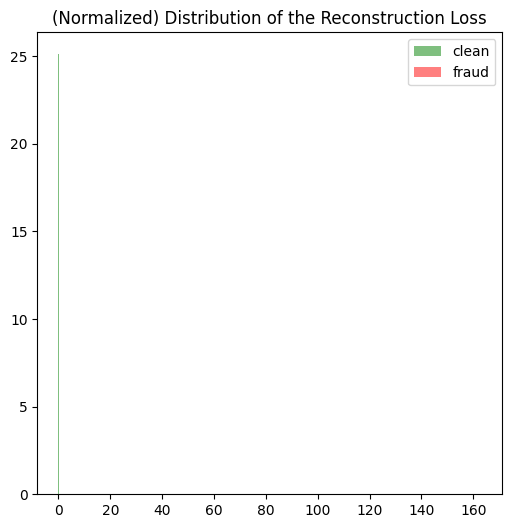

In [28]:
clean = mse[y_test==0]
fraud = mse[y_test==1]

fig, ax = plt.subplots(figsize=(6,6))

ax.hist(clean, bins=5, density=True, label="clean", alpha=.5, color="green")
ax.hist(fraud, bins=5, density=True, label="fraud", alpha=.5, color="red")

plt.title("(Normalized) Distribution of the Reconstruction Loss")
plt.legend()
plt.show()

In [20]:
THRESHOLD = 10

def mad_score(points):
    """https://www.itl.nist.gov/div898/handbook/eda/section3/eda35h.htm """
    m = np.median(points)
    ad = np.abs(points - m)
    mad = np.median(ad)
    
    return 0.6745 * ad / mad

z_scores = mad_score(mse)
outliers = z_scores > THRESHOLD


Text(50.722222222222214, 0.5, 'True Label')

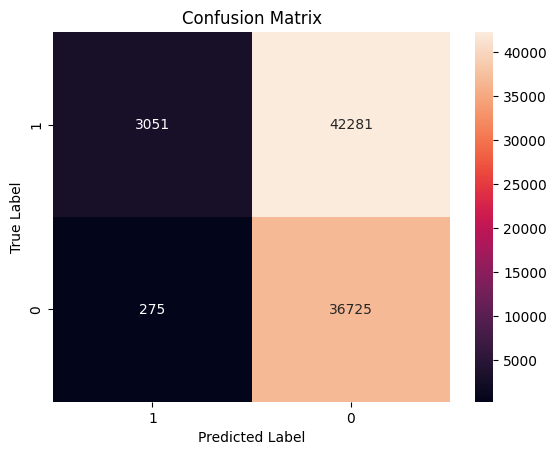

In [22]:
from sklearn.metrics import confusion_matrix, precision_recall_curve

cm = confusion_matrix(y_test, outliers)
plt.title("Confusion Matrix")
ax = sns.heatmap(cm, annot=True, fmt='0.0f')
ax.invert_yaxis()
ax.invert_xaxis()
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')

In [23]:
tn, fp, fn, tp = cm.ravel()
print("True Negative:", tn)
print("False Negative:", fn)
print("True Positive:", tp)
print("False Positive:", fp)

True Negative: 36725
False Negative: 42281
True Positive: 3051
False Positive: 275
